# Sequential / Multi-Hop Chain RAG (Multi-Agent RAG Paradigm)

## Table of Contents
1. [What is Sequential / Multi-Hop Chain RAG?](#what-is-sequential--multi-hop-chain-rag)
2. [How It Works - The Complete Process](#how-it-works---the-complete-process)
3. [Full Workflow Diagram](#full-workflow-diagram)
4. [Why and When to Use It](#why-and-when-to-use-it)
5. [Pros and Cons](#pros-and-cons)
6. [Building from Scratch in LangGraph](#building-from-scratch-in-langgraph)
7. [Real-World Case Study: Corporate Supply Chain Risk Audit](#real-world-case-study-corporate-supply-chain-risk-audit)

---

## What is Sequential / Multi-Hop Chain RAG?

**Sequential / Multi-Hop Chain RAG** is a retrieval-augmented generation paradigm where a single complex question cannot be answered by a single database lookup. Instead, the system must perform **multiple sequential retrieval steps (hops)**, where the output of each hop dynamically determines the query for the next hop.

### The Core Insight

Consider this question:

> "Is the critical chip supplier of QuantumTech Inc. owned by any entity currently under U.S. sanctions?"

No single database contains the full answer. You need to:

1. **Hop 1**: Look up QuantumTech's supply chain records to find who their critical chip supplier is (e.g., "CryoSystems Ltd.").
2. **Hop 2**: Look up corporate registries to find CryoSystems Ltd.'s parent holding company (e.g., "Vanguard Industrial Holdings").
3. **Hop 3**: Look up OFAC/sanctions databases to check if Vanguard Industrial Holdings is sanctioned (e.g., "Yes, under EO-14071 for Belarus operations").
4. **Hop 4**: Look up Vanguard's global subsidiary list to identify all operations in sanctioned jurisdictions (e.g., "Active subsidiaries in Minsk, Belarus and Crimea, Ukraine").

Each hop **depends on the findings of the previous hop**. This is the fundamental difference from parallel retrieval (like Hierarchical RAG) where all queries are independent.

### Key Terminology

| Term | Definition |
|------|-----------|
| **Hop** | A single retrieval step that queries a knowledge source and returns findings |
| **Multi-Hop Chain** | The sequential pipeline of dependent hops that builds up a complete answer |
| **Hop Query** | A dynamically formulated search query, generated from prior hop findings |
| **Hop Findings** | The synthesized result of a single retrieval step |
| **Chain Lineage** | The traceable, auditable sequence of queries and findings across all hops |
| **Bridge Entity** | An entity discovered in one hop that becomes the search target of the next hop |

### How It Differs from Other RAG Paradigms

| Feature | Single-Shot RAG | Hierarchical RAG | Sequential Multi-Hop RAG |
|---------|----------------|-------------------|--------------------------|
| **Retrieval Steps** | 1 | Multiple (parallel) | Multiple (sequential) |
| **Query Dependencies** | None | Independent sub-queries | Each query depends on prior findings |
| **Agent Structure** | Single retriever | Orchestrator + parallel workers | Analyst loop + sequential executor |
| **Best For** | Simple factual lookups | Multi-domain audits | Investigative, chain-of-evidence queries |
| **Latency** | Lowest | Medium (parallel) | Higher (sequential) |
| **Reasoning Depth** | Shallow | Broad but shallow | Deep and connected |

---

## How It Works - The Complete Process

The Sequential Multi-Hop Chain RAG operates as a **controlled reasoning loop** between two core components:

### Step-by-Step Process

#### Phase 1: Query Intake and Initial Decomposition
The system receives a complex user inquiry. An **Investigative Analyst** (LLM-powered reasoning node) analyzes the query and identifies that it requires multi-hop retrieval. It formulates the **first hop query** targeting the most foundational piece of missing information.

#### Phase 2: The Hop Loop (Iterative Retrieval)
The system enters a loop:

1. **Analyst Node** formulates a targeted query based on:
   - The original user question
   - All findings accumulated from previous hops
   - What information is still missing

2. **Search Executor Node** takes the formulated query and:
   - Qu```eries the appropriate knowledge source (vector store, database, API)
   - Retrieves raw documents/records
   - Synthesizes the findings into a concise, fact-grounded summary

3. **State Update**: The hop findings are appended to the state, the hop counter increments, and control returns to the Analyst.

4. **Analyst Decision**: The Analyst reviews all accumulated findings and decides:
   - **"continue"**: More information is needed. Formulate the next hop query.
   - **"synthesize"**: All necessary evidence has been gathered. Compile the final report.

#### Phase 3: Final Synthesis
Once the Analyst determines that sufficient evidence has been collected across all hops, it compiles a comprehensive, traceable report that:
- Chains all findings into a coherent narrative
- Shows the exact hop-by-hop investigative trail
- Provides a clear, evidence-backed conclusion

### The Information Flow


```mermaid
flowchart TD
    User["User Question"] --> Analyst1["Analyst Node:<br>'What supplier provides chips to QuantumTech?'"]
    Analyst1 --> Search1["Search Supply Chain DB"]
    Search1 --> Finding1["Hop 1 Finding:<br>'CryoSystems Ltd.'"]
    
    Finding1 --> Analyst2["Analyst Node:<br>'Who is the parent company of CryoSystems Ltd.?'"]
    Analyst2 --> Search2["Search Corporate Registry"]
    Search2 --> Finding2["Hop 2 Finding:<br>'Vanguard Industrial Holdings (78% stake)'"]
    
    Finding2 --> Analyst3["Analyst Node:<br>'Is Vanguard Industrial Holdings under any sanctions?'"]
    Analyst3 --> Search3["Search OFAC Sanctions DB"]
    Search3 --> Finding3["Hop 3 Finding:<br>'Yes, EO-14071, Belarus operations'"]
    
    Finding3 --> Analyst4["Analyst Node:<br>'What subsidiaries does Vanguard operate in sanctioned jurisdictions?'"]
    Analyst4 --> Search4["Search Global Subsidiaries DB"]
    Search4 --> Finding4["Hop 4 Finding:<br>'Minsk Belarus, Crimea Ukraine'"]
    
    Finding4 --> Analyst5["Analyst Node:<br>SYNTHESIZE (All evidence gathered)"]
    Analyst5 --> Report["Final Investigative Report"]

    classDef analyst fill:#e1f5fe,stroke:#0288d1,stroke-width:2px;
    classDef search fill:#e8f5e9,stroke:#388e3c,stroke-width:1px;
    classDef finding fill:#fff3e0,stroke:#f57c00,stroke-width:1px;
    classDef io fill:#eceff1,stroke:#607d8b,stroke-width:2px;

    class User,Report io;
    class Analyst1,Analyst2,Analyst3,Analyst4,Analyst5 analyst;
    class Search1,Search2,Search3,Search4 search;
    class Finding1,Finding2,Finding3,Finding4 finding;
```


---


```mermaid
flowchart TB
    subgraph SequentialMultiHop["SEQUENTIAL MULTI-HOP RAG ARCHITECTURE"]
        direction TB
        Analyst["Investigative Lead Analyst<br>(LLM Router)"]
        Executor["Multi-Source Search Executor<br>(RAG Retriever)"]
        Synthesizer["Synthesizer<br>(Final Report)"]

        Analyst -- "Formulate Query" --> Executor
        Executor -- "Hop Findings" --> Analyst
        Analyst -- "When all hops done" --> Synthesizer
    end

    classDef primary fill:#e1f5fe,stroke:#0288d1,stroke-width:2px;
    classDef secondary fill:#e8f5e9,stroke:#388e3c,stroke-width:2px;
    classDef final fill:#fff3e0,stroke:#f57c00,stroke-width:2px;
    
    class Analyst primary;
    class Executor secondary;
    class Synthesizer final;
```

### Detailed State Machine

```mermaid
flowchart TD
    Start([START]) --> Analyst["Investigative Analyst<br>(Review findings & formulate query)"]
    Analyst --> Decision{"Route Decision"}
    
    Decision -- "continue" --> Executor["Multi-Source Search Executor Node<br><br>- Query appropriate DB<br>- Synthesize findings<br>- Append to hop_findings<br>- Increment hop counter"]
    Decision -- "synthesize" --> Synthesizer["Synthesizer<br>(Compile Report)"]
    
    Executor --> Analyst
    Synthesizer --> End([END])

    classDef boundary fill:#eceff1,stroke:#607d8b,stroke-width:2px;
    classDef process fill:#e1f5fe,stroke:#0288d1,stroke-width:2px;
    classDef decision fill:#fff9c4,stroke:#fbc02d,stroke-width:2px;
    
    class Start,End boundary;
    class Analyst,Executor,Synthesizer process;
    class Decision decision;
```


## Why and When to Use It

### When to Use Sequential Multi-Hop RAG

1. **Investigative Queries**: Questions that require following a chain of evidence across multiple data sources (e.g., forensic accounting, compliance audits, intelligence analysis).

2. **Entity Resolution Chains**: When you need to resolve relationships like "Company A -> Supplier B -> Parent Company C -> Sanctioned Entity D".

3. **Temporal Reasoning**: Questions requiring sequential time-based lookups (e.g., "What was the stock price of company X on the day AFTER they filed the patent that was LATER cited in lawsuit Y?").

4. **Dependency-Driven Research**: Academic research where Paper A cites Paper B, which builds on Dataset C, which was generated by Method D.

5. **Root Cause Analysis**: Debugging chains where "Error A was caused by Config B, which was changed by Deploy C, which was triggered by PR D".

### When NOT to Use It

- **Simple factual lookups**: Use single-shot RAG instead.
- **Multi-domain but independent queries**: Use Hierarchical RAG (parallel workers) instead.
- **Real-time, latency-sensitive applications**: Sequential hops add latency.
- **Questions where all sub-queries are known upfront**: Use parallel decomposition instead.

---

## Pros and Cons

### Pros

| Advantage | Description |
|-----------|-------------|
| **Deep Reasoning** | Can answer questions that require connecting dots across multiple knowledge sources |
| **Dynamic Query Formulation** | Each hop's query is intelligently crafted based on actual findings, not just template-based decomposition |
| **Traceable Audit Trail** | Every hop is logged with its query and findings, creating a fully auditable chain of evidence |
| **Handles Unknown Unknowns** | The system discovers what it needs to search for next based on what it finds, rather than requiring all sub-queries upfront |
| **Adaptive Depth** | The number of hops adapts to the complexity of the question - simple chains terminate early |
| **Reduced Hallucination** | Each hop is grounded in actual retrieved evidence before proceeding |

### Cons

| Disadvantage | Description |
|--------------|-------------|
| **Higher Latency** | Sequential nature means each hop must complete before the next begins |
| **Error Propagation** | A wrong finding in Hop 1 cascades incorrect queries through all subsequent hops |
| **Higher Token Cost** | Multiple LLM calls for routing decisions + synthesis at each hop |
| **Complexity** | More complex to implement and debug than single-shot or parallel RAG |
| **Loop Risk** | Without proper termination conditions (max hops), the system could loop indefinitely |
| **Requires Rich Knowledge Bases** | Each hop must find actionable "bridge entities" to chain to the next hop |

---

## Real-World Case Study: Corporate Supply Chain Risk Audit

### Scenario

A multinational defense contractor, **AeroShield Defense Corp.**, is undergoing a **supplier compliance audit** mandated by the U.S. Department of Defense (DoD). The audit requires verifying that none of their critical component suppliers are owned by entities under U.S. sanctions or operating in sanctioned jurisdictions.

### The Question

> "Identify the primary supplier of radiation-hardened microprocessors to AeroShield Defense Corp., determine their corporate ownership structure, check if any parent entities are under OFAC sanctions, and map all subsidiary operations in sanctioned jurisdictions."

### Why Multi-Hop is Required

This question cannot be answered in a single search because:
- **Hop 1** discovers the supplier name (unknown beforehand)
- **Hop 2** discovers the parent company (depends on Hop 1's result)
- **Hop 3** discovers sanctions status (depends on Hop 2's result)
- **Hop 4** discovers subsidiary locations (depends on Hop 2's result + Hop 3's context)

### Expected Hop Chain

```
Hop 1: "Who supplies radiation-hardened microprocessors to AeroShield Defense Corp.?"
  --> Finding: "CryoSystems Ltd. (Contract #DOD-SC-2024-4471)"

Hop 2: "Who is the parent/holding company of CryoSystems Ltd.?"
  --> Finding: "Vanguard Industrial Holdings (78.3% stake, Luxembourg HQ)"

Hop 3: "Is Vanguard Industrial Holdings under any OFAC or international sanctions?"
  --> Finding: "Yes - Executive Order 14071, Belarus-related sanctions, listed 2023-09-15"

Hop 4: "What subsidiaries does Vanguard Industrial Holdings operate in sanctioned jurisdictions?"
  --> Finding: "VIH-Minsk (Belarus), VIH-Crimea (Ukraine), VIH-Tehran (Iran)"
````

### Final Synthesized Report

The system compiles all hop findings into a structured **Supply Chain Risk Assessment** with:
- A risk severity grade (CRITICAL)
- The complete chain of evidence
- Regulatory implications (ITAR violations, CAATSA exposure)
- Recommended actions (contract termination, alternative sourcing)

### Implementation

The complete implementation follows in the accompanying Python file. It includes:
- 4 mock knowledge bases (Supply Chain, Corporate Registry, OFAC Sanctions, Global Subsidiaries)
- Dynamic dual-provider LLM loading (OpenAI / Groq)
- Full hop-by-hop console tracing
- Comprehensive final synthesis
- Chain lineage audit log

## Complete Implementation Code
# Building From Scratch In Langgraph

In [ ]:
"""
Sequential / Multi-Hop Chain RAG Pattern - LangGraph Implementation
====================================================================

This script implements a Sequential Multi-Hop Chain RAG pattern for an
Investigative Corporate Intelligence & Supply Chain Risk Audit scenario.

Key Concepts:
- Multi-Hop Retrieval: Each hop's findings dynamically determine the next hop's query.
- Bridge Entities: Entities discovered in one hop become the search target of the next.
- Chain Lineage: Full auditable trail of queries and findings across all hops.
- Dynamic Query Formulation: LLM reasons about what to search next based on accumulated evidence.

Scenario: AeroShield Defense Corp supplier compliance audit
- Hop 1: Discover critical supplier from supply chain records
- Hop 2: Resolve parent/holding company from corporate registry
- Hop 3: Check parent company against OFAC sanctions lists
- Hop 4: Map subsidiary operations in sanctioned jurisdictions
"""


In [2]:

import os
from typing import Literal, List
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState

# # Load environment variables from the parent directory .env
# load_dotenv(dotenv_path=os.path.join(os.path.dirname(os.path.abspath(__file__)), '..', '.env'))
# Also try current directory
load_dotenv()

True

In [3]:

# ==============================================================================
# Dynamic Dual-Provider LLM Setup (OpenAI / Groq)
# ==============================================================================

if os.environ.get("OPENAI_API_KEY"):
    print("[INFO] Detected OpenAI API Key. Running with OpenAI (gpt-4o)...")
    from langchain_openai import ChatOpenAI
    analyst_model = ChatOpenAI(model='gpt-4o', temperature=0)
    search_model = ChatOpenAI(model='gpt-4o-mini', temperature=0.1)
elif os.environ.get("GROQ_API_KEY"):
    print("[INFO] Detected Groq API Key. Running with Groq (llama-3.3-70b-versatile & llama-3.1-8b-instant)...")
    from langchain_groq import ChatGroq
    analyst_model = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
    search_model = ChatGroq(model='llama-3.1-8b-instant', temperature=0.1)
else:
    raise ValueError("Missing credentials. Set OPENAI_API_KEY or GROQ_API_KEY in your .env file.")

[INFO] Detected Groq API Key. Running with Groq (llama-3.3-70b-versatile & llama-3.1-8b-instant)...


In [10]:

# ==============================================================================
# Step 1: Define Mock Knowledge Bases (4 Separate Corporate Databases)
# ==============================================================================

# Database 1: Supply Chain Contract Records
SUPPLY_CHAIN_DB = [
    {
        "buyer": "AeroShield Defense Corp.",
        "component": "Radiation-hardened microprocessors (Rad-Hard MPU Series RH-7000)",
        "supplier": "CryoSystems Ltd.",
        "contract_id": "DOD-SC-2024-4471",
        "contract_value": "$24.8 Million USD (3-year framework agreement)",
        "criticality": "CRITICAL - Sole-source supplier, no qualified alternative",
        "notes": (
            "CryoSystems Ltd. supplies all radiation-hardened microprocessors used in "
            "AeroShield's satellite guidance and missile defense systems. Lead time: 18 months. "
            "Components are ITAR-controlled under USML Category XI. "
            "Last quality audit: March 2025 - PASSED with zero non-conformances."
        ),
    },
    {
        "buyer": "AeroShield Defense Corp.",
        "component": "Titanium airframe structural panels (Grade 5 Ti-6Al-4V)",
        "supplier": "NovaMetal Industries GmbH",
        "contract_id": "DOD-SC-2023-3892",
        "contract_value": "$12.1 Million USD (annual renewal)",
        "criticality": "HIGH - Dual-source available (backup: Kobe Steel Japan)",
        "notes": (
            "NovaMetal supplies precision-machined titanium panels for F-35 subcontract work. "
            "Alternative supplier Kobe Steel qualified in Q2 2024."
        ),
    },
]

# Database 2: Corporate Ownership Registry
CORPORATE_REGISTRY_DB = [
    {
        "company": "CryoSystems Ltd.",
        "jurisdiction": "United Kingdom (Companies House: #09284571)",
        "parent_company": "Vanguard Industrial Holdings S.A.",
        "parent_jurisdiction": "Luxembourg (RCS Luxembourg: B-198247)",
        "ownership_stake": "78.3%",
        "board_control": "Vanguard appoints 4 of 6 board directors",
        "notes": (
            "CryoSystems Ltd. was acquired by Vanguard Industrial Holdings in 2019. "
            "Remaining 21.7% held by original founders (Dr. Elena Kosovic, Dr. Raj Menon). "
            "Vanguard Industrial Holdings is a diversified industrial conglomerate with "
            "operations across defense electronics, rare earth mining, and semiconductor fabrication."
        ),
    },
    {
        "company": "NovaMetal Industries GmbH",
        "jurisdiction": "Germany (Handelsregister: HRB 142876)",
        "parent_company": "Rheinmetall AG",
        "parent_jurisdiction": "Germany (Frankfurt Stock Exchange: RHM)",
        "ownership_stake": "100% (wholly-owned subsidiary)",
        "board_control": "Full Rheinmetall corporate governance",
        "notes": "NovaMetal is a wholly-owned subsidiary of Rheinmetall AG, a publicly traded German defense contractor.",
    },
]

# Database 3: OFAC Sanctions & Regulatory Enforcement Lists
SANCTIONS_DB = [
    {
        "entity": "Vanguard Industrial Holdings S.A.",
        "sanction_authority": "U.S. Department of Treasury - OFAC (Office of Foreign Assets Control)",
        "sanction_type": "Sectoral Sanctions (SSI List)",
        "executive_order": "Executive Order 14071 (Prohibitions on Certain Imports, Exports, and New Investment with Respect to Belarus)",
        "date_listed": "2023-09-15",
        "reason": (
            "Vanguard Industrial Holdings was designated under EO-14071 due to its subsidiary "
            "VIH-Minsk operating semiconductor fabrication lines in Belarus that were found to be "
            "supplying dual-use electronic components to Belarusian state defense enterprises. "
            "OFAC determined VIH-Minsk provided material support to the Belarusian military-industrial complex."
        ),
        "status": "ACTIVE - No delisting application filed",
        "penalties": "U.S. persons prohibited from significant transactions; asset freeze on U.S.-nexus properties.",
    },
    {
        "entity": "Rheinmetall AG",
        "sanction_authority": "None",
        "sanction_type": "NOT SANCTIONED",
        "executive_order": "N/A",
        "date_listed": "N/A",
        "reason": "Rheinmetall AG is a NATO-allied defense contractor with no sanctions designations.",
        "status": "CLEAR",
        "penalties": "None",
    },
]

# Database 4: Global Subsidiary Operations Registry
SUBSIDIARIES_DB = [
    {
        "parent_company": "Vanguard Industrial Holdings S.A.",
        "subsidiaries": [
            {"name": "VIH-Minsk", "country": "Belarus", "city": "Minsk", "activity": "Semiconductor fabrication (dual-use components)", "sanctions_jurisdiction": True},
            {"name": "VIH-Crimea", "country": "Ukraine (Russian-occupied Crimea)", "city": "Sevastopol", "activity": "Rare earth mineral processing", "sanctions_jurisdiction": True},
            {"name": "VIH-Tehran", "country": "Iran", "city": "Tehran", "activity": "Industrial electronics assembly", "sanctions_jurisdiction": True},
            {"name": "VIH-Luxembourg", "country": "Luxembourg", "city": "Luxembourg City", "activity": "Corporate headquarters and treasury", "sanctions_jurisdiction": False},
            {"name": "VIH-Singapore", "country": "Singapore", "city": "Singapore", "activity": "Asia-Pacific semiconductor distribution", "sanctions_jurisdiction": False},
            {"name": "CryoSystems Ltd.", "country": "United Kingdom", "city": "Cambridge", "activity": "Radiation-hardened microprocessor design and manufacturing", "sanctions_jurisdiction": False},
        ]
    },
    {
        "parent_company": "Rheinmetall AG",
        "subsidiaries": [
            {"name": "NovaMetal Industries GmbH", "country": "Germany", "city": "Dusseldorf", "activity": "Titanium structural manufacturing", "sanctions_jurisdiction": False},
            {"name": "Rheinmetall Defence Australia", "country": "Australia", "city": "Melbourne", "activity": "Military vehicle systems", "sanctions_jurisdiction": False},
        ]
    },
]

In [11]:


# ==============================================================================
# Step 2: Define the Unified Multi-Source Retrieval Tool
# ==============================================================================

def search_all_databases(query: str) -> str:
    """
    Searches across all four corporate intelligence databases and returns
    matching results. This simulates a unified RAG retriever that spans
    multiple knowledge sources.
    """
    results = []
    query_lower = query.lower()

    # Search Supply Chain DB
    for record in SUPPLY_CHAIN_DB:
        searchable = f"{record['buyer']} {record['supplier']} {record['component']} {record['notes']}".lower()
        if any(term in searchable for term in query_lower.split() if len(term) > 3):
            results.append(
                f"[SOURCE: Supply Chain Records - Contract {record['contract_id']}]\n"
                f"Buyer: {record['buyer']}\n"
                f"Supplier: {record['supplier']}\n"
                f"Component: {record['component']}\n"
                f"Contract Value: {record['contract_value']}\n"
                f"Criticality: {record['criticality']}\n"
                f"Details: {record['notes']}"
            )

    # Search Corporate Registry DB
    for record in CORPORATE_REGISTRY_DB:
        searchable = f"{record['company']} {record['parent_company']} {record['notes']}".lower()
        if any(term in searchable for term in query_lower.split() if len(term) > 3):
            results.append(
                f"[SOURCE: Corporate Registry - {record['jurisdiction']}]\n"
                f"Company: {record['company']}\n"
                f"Parent Company: {record['parent_company']} ({record['parent_jurisdiction']})\n"
                f"Ownership Stake: {record['ownership_stake']}\n"
                f"Board Control: {record['board_control']}\n"
                f"Details: {record['notes']}"
            )

    # Search Sanctions DB
    for record in SANCTIONS_DB:
        searchable = f"{record['entity']} {record['reason']} {record['sanction_type']}".lower()
        if any(term in searchable for term in query_lower.split() if len(term) > 3):
            results.append(
                f"[SOURCE: OFAC Sanctions Database]\n"
                f"Entity: {record['entity']}\n"
                f"Authority: {record['sanction_authority']}\n"
                f"Type: {record['sanction_type']}\n"
                f"Executive Order: {record['executive_order']}\n"
                f"Date Listed: {record['date_listed']}\n"
                f"Reason: {record['reason']}\n"
                f"Status: {record['status']}\n"
                f"Penalties: {record['penalties']}"
            )

    # Search Subsidiaries DB
    for record in SUBSIDIARIES_DB:
        searchable = f"{record['parent_company']}".lower()
        sub_names = " ".join([s['name'] + " " + s['country'] + " " + s['activity'] for s in record['subsidiaries']]).lower()
        full_searchable = searchable + " " + sub_names
        if any(term in full_searchable for term in query_lower.split() if len(term) > 3):
            sub_list = "\n".join([
                f"  - {s['name']} | {s['city']}, {s['country']} | Activity: {s['activity']} | "
                f"Sanctioned Jurisdiction: {'YES' if s['sanctions_jurisdiction'] else 'No'}"
                for s in record['subsidiaries']
            ])
            results.append(
                f"[SOURCE: Global Subsidiaries Registry]\n"
                f"Parent Company: {record['parent_company']}\n"
                f"Subsidiaries:\n{sub_list}"
            )

    if not results:
        return f"No records found matching query: '{query}'"

    return "\n\n" + ("=" * 60 + "\n").join(results)



In [12]:

# ==============================================================================
# Step 3: Define the Multi-Hop Graph State
# ==============================================================================

class MultiHopState(MessagesState):
    """State for the sequential multi-hop chain."""
    current_hop: int          # Which hop we are on (starts at 1)
    max_hops: int             # Safety limit for the loop (default: 6)
    hop_queries: list         # Lineage of dynamically formulated sub-queries
    hop_findings: list        # Synthesized findings from each hop
    next_step: str            # Routing decision: "continue" or "synthesize"
    final_report: str         # The completed investigation report


In [13]:

# ==============================================================================
# Step 4: Define the Structured Router Schema
# ==============================================================================

class HopDecision(BaseModel):
    """Structured output for the Investigative Analyst's routing decision."""
    next_step: Literal["continue", "synthesize"] = Field(
        description="Choose 'continue' if more information is needed via another search hop. Choose 'synthesize' if all necessary evidence has been gathered to answer the original question."
    )
    next_query: str = Field(
        default="",
        description="The dynamically formulated search query for the next hop. Must be based on findings from previous hops. Leave empty if synthesizing."
    )
    reasoning: str = Field(
        description="Explain what has been discovered so far, what bridge entity was found, and what information gap remains."
    )


# Bind structured output to the analyst model
structured_analyst = analyst_model.with_structured_output(HopDecision)



In [14]:


# ==============================================================================
# Step 5: Implement Graph Nodes
# ==============================================================================

def investigative_analyst(state: MultiHopState) -> dict:
    """
    The reasoning engine that reviews accumulated evidence, formulates the
    next hop query based on bridge entities found, and decides when to stop.
    """
    # Build context from all previous hops
    hop_context = ""
    queries = state.get("hop_queries", [])
    findings = state.get("hop_findings", [])

    for i, (q, f) in enumerate(zip(queries, findings), 1):
        hop_context += f"--- Hop {i} ---\nQuery: {q}\nFinding: {f}\n\n"

    current_hop = state.get("current_hop", 1)
    max_hops = state.get("max_hops", 6)

    # Force synthesis if we hit the max hop limit
    if current_hop > max_hops:
        print(f"\n[Analyst] Max hops ({max_hops}) reached. Forcing synthesis...")
        return {
            "next_step": "synthesize",
            "messages": [AIMessage(
                content=f"[Analyst] Maximum hop limit reached ({max_hops}). Proceeding to synthesis.",
                name="InvestigativeAnalyst"
            )]
        }

    system_prompt = SystemMessage(content=(
        "You are an Investigative Lead Analyst conducting a sequential multi-hop "
        "corporate intelligence investigation.\n\n"
        "YOUR TASK: Answer the user's original question by performing sequential searches. "
        "Each search (hop) should build on the findings of the previous hop.\n\n"
        "KEY RULES:\n"
        "1. Each hop query must be specific and targeted at ONE piece of information.\n"
        "2. Use 'bridge entities' - names, companies, IDs discovered in previous hops - "
        "as the search target for the next hop.\n"
        "3. Choose 'continue' if you still need more evidence to fully answer the question.\n"
        "4. Choose 'synthesize' ONLY when you have gathered ALL the evidence needed.\n"
        "5. Do NOT repeat queries you have already asked.\n\n"
        f"CURRENT HOP: {current_hop} of {max_hops}\n\n"
        f"PREVIOUS HOP RESULTS:\n{hop_context if hop_context else 'None yet - this is the first hop.'}\n"
    ))

    # Get structured decision from LLM
    decision = structured_analyst.invoke([system_prompt] + state["messages"])

    print(f"\n{'=' * 70}")
    print(f"[Analyst] Hop {current_hop} Decision: {decision.next_step.upper()}")
    print(f"   Reasoning: {decision.reasoning}")

    update = {
        "next_step": decision.next_step,
        "messages": [AIMessage(
            content=f"[Analyst Hop {current_hop}]: {decision.reasoning}",
            name="InvestigativeAnalyst"
        )]
    }

    if decision.next_step == "continue" and decision.next_query:
        print(f"   Next Query: '{decision.next_query}'")
        update["hop_queries"] = queries + [decision.next_query]

    return update


def search_executor(state: MultiHopState) -> dict:
    """
    Executes the latest hop query against the unified multi-source knowledge base,
    then uses an LLM to synthesize the raw results into a concise finding.
    """
    queries = state.get("hop_queries", [])
    findings = state.get("hop_findings", [])
    current_hop = state.get("current_hop", 1)

    if not queries:
        return {
            "hop_findings": findings + ["No query was provided for this hop."],
            "current_hop": current_hop + 1,
        }

    latest_query = queries[-1]
    print(f"\n[Search Executor] Hop {current_hop} - Querying databases for: '{latest_query}'...")

    # Execute the search across all databases
    raw_results = search_all_databases(latest_query)

    # Use LLM to synthesize findings into a concise summary
    synthesis_prompt = (
        f"You are a research assistant. Synthesize the following database search results "
        f"into a concise, fact-grounded finding. Preserve ALL specific names, numbers, dates, "
        f"and identifiers exactly as they appear in the source data.\n\n"
        f"Search Query: {latest_query}\n\n"
        f"Raw Database Results:\n{raw_results}\n\n"
        f"Provide a clear, concise summary of the key facts found. "
        f"Include source citations in [brackets]."
    )

    synthesis = search_model.invoke([HumanMessage(content=synthesis_prompt)])
    finding = synthesis.content

    print(f"   Finding: {finding[:200]}...")

    return {
        "hop_findings": findings + [finding],
        "current_hop": current_hop + 1,
        "messages": [AIMessage(
            content=f"[Search Result Hop {current_hop}]: {finding}",
            name="SearchExecutor"
        )]
    }


def final_synthesizer(state: MultiHopState) -> dict:
    """
    Compiles all sequential hop findings into a comprehensive, traceable
    investigative intelligence report.
    """
    print(f"\n{'=' * 70}")
    print("[Synthesizer] Compiling final multi-hop investigative report...")

    queries = state.get("hop_queries", [])
    findings = state.get("hop_findings", [])

    # Build the hop chain narrative
    chain_narrative = ""
    for i, (q, f) in enumerate(zip(queries, findings), 1):
        chain_narrative += f"### Hop {i}\n**Query**: {q}\n**Finding**: {f}\n\n"

    synthesis_prompt = SystemMessage(content=(
        "You are an Investigative Intelligence Report Compiler. You have completed a "
        "sequential multi-hop investigation. Compile ALL findings into a comprehensive, "
        "structured Corporate Intelligence & Supply Chain Risk Assessment Report.\n\n"
        "REPORT STRUCTURE:\n"
        "1. EXECUTIVE SUMMARY - Brief overview of the investigation and key conclusion\n"
        "2. INVESTIGATION CHAIN - Step-by-step hop trail showing how each finding led to the next\n"
        "3. KEY FINDINGS - Detailed breakdown of each critical discovery\n"
        "4. RISK ASSESSMENT - Severity grade (CRITICAL/HIGH/MEDIUM/LOW) with justification\n"
        "5. REGULATORY IMPLICATIONS - Specific laws, executive orders, and compliance issues\n"
        "6. RECOMMENDED ACTIONS - Concrete next steps for the organization\n\n"
        f"HOP-BY-HOP INVESTIGATION TRAIL:\n{chain_narrative}\n"
        "IMPORTANT: Preserve ALL source citations, entity names, dates, contract IDs, "
        "and executive order numbers exactly as found. This report must be audit-ready."
    ))

    response = analyst_model.invoke([synthesis_prompt] + state["messages"])

    return {
        "final_report": response.content,
        "messages": [AIMessage(content=response.content, name="Synthesizer")]
    }

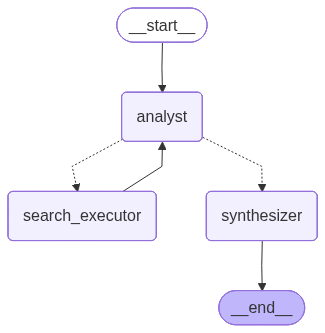

In [15]:

# ==============================================================================
# Step 6: Build Conditional Router and Assemble the Graph
# ==============================================================================

def route_analyst_decision(state: MultiHopState) -> str:
    """Routes based on the analyst's structured decision."""
    next_step = state.get("next_step", "synthesize")
    current_hop = state.get("current_hop", 1)
    max_hops = state.get("max_hops", 6)

    if next_step == "synthesize" or current_hop > max_hops:
        return "synthesizer"
    return "search_executor"


# Build the graph
workflow = StateGraph(MultiHopState)

# Add nodes
workflow.add_node("analyst", investigative_analyst)
workflow.add_node("search_executor", search_executor)
workflow.add_node("synthesizer", final_synthesizer)

# Wire edges
workflow.add_edge(START, "analyst")
workflow.add_conditional_edges(
    "analyst",
    route_analyst_decision,
    {
        "search_executor": "search_executor",
        "synthesizer": "synthesizer",
    }
)
workflow.add_edge("search_executor", "analyst")  # Loop back after each hop
workflow.add_edge("synthesizer", END)

# Compile
compiled_graph = workflow.compile()
compiled_graph

In [16]:

# ==============================================================================
# Step 7: Execute the Multi-Hop Investigation
# ==============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 80)
    print("SEQUENTIAL MULTI-HOP CHAIN RAG - Supply Chain Risk Audit")
    print("=" * 80)

    user_query = (
        "Identify the primary supplier of radiation-hardened microprocessors to "
        "AeroShield Defense Corp., determine their corporate ownership structure, "
        "check if any parent entities are under OFAC sanctions, and map all "
        "subsidiary operations in sanctioned jurisdictions."
    )

    print(f"\nInvestigation Query:\n\"{user_query}\"\n")

    # Initialize state with hop tracking
    inputs = {
        "messages": [HumanMessage(content=user_query)],
        "current_hop": 1,
        "max_hops": 6,
        "hop_queries": [],
        "hop_findings": [],
        "next_step": "continue",
        "final_report": "",
    }

    # Run the graph
    result = compiled_graph.invoke(inputs, {"recursion_limit": 30})

    # Print final report
    print("\n" + "=" * 80)
    print("FINAL INVESTIGATIVE INTELLIGENCE REPORT")
    print("=" * 80)
    print(result["messages"][-1].content)
    print("=" * 80)

    # Print hop chain lineage audit
    print("\nHOP CHAIN LINEAGE AUDIT")
    print("=" * 80)
    hop_queries = result.get("hop_queries", [])
    hop_findings = result.get("hop_findings", [])
    for i, (q, f) in enumerate(zip(hop_queries, hop_findings), 1):
        print(f"\n[Hop {i}]")
        print(f"  Query:   {q}")
        finding_preview = f[:150] + "..." if len(f) > 150 else f
        print(f"  Finding: {finding_preview}")

    print(f"\nTotal Hops Executed: {len(hop_queries)}")

    # Context footprint analysis
    print("\nCONTEXT FOOTPRINT ANALYSIS")
    print("=" * 80)
    total_chars = 0
    for idx, msg in enumerate(result["messages"]):
        name = getattr(msg, "name", None) or "User"
        content_len = len(msg.content) if msg.content else 0
        total_chars += content_len
        print(f"[{idx+1:02d}] {name:<22}: {content_len:<5} characters")

    print(f"\nTotal characters in message state: {total_chars}")
    print("=" * 80 + "\n")



SEQUENTIAL MULTI-HOP CHAIN RAG - Supply Chain Risk Audit

Investigation Query:
"Identify the primary supplier of radiation-hardened microprocessors to AeroShield Defense Corp., determine their corporate ownership structure, check if any parent entities are under OFAC sanctions, and map all subsidiary operations in sanctioned jurisdictions."




[Analyst] Hop 1 Decision: CONTINUE
   Reasoning: To answer the original question, we first need to identify the primary supplier of radiation-hardened microprocessors to AeroShield Defense Corp. This will serve as our bridge entity for the next hop.
   Next Query: 'Who is the primary supplier of radiation-hardened microprocessors to AeroShield Defense Corp.?'

[Search Executor] Hop 1 - Querying databases for: 'Who is the primary supplier of radiation-hardened microprocessors to AeroShield Defense Corp.?'...
   Finding: **Primary Supplier of Radiation-Hardened Microprocessors to AeroShield Defense Corp.**

CryoSystems Ltd. is the primary supplier of radiation-hardened microprocessors (Rad-Hard MPU Series RH-7000) to ...

[Analyst] Hop 2 Decision: CONTINUE
   Reasoning: We have identified CryoSystems Ltd. as the primary supplier of radiation-hardened microprocessors to AeroShield Defense Corp. and its corporate ownership structure under Vanguard Industrial Holdings S.A., which is under 